# Phase 3 — Machine Learning Models
**Project:** Huawei Telecom Complaint Analytics & Network Intelligence Platform  
**Deliverable:** D4 — Trained ML Models  
**Author:** Your Name  

---
## Table of Contents
1. Environment Setup
2. Load Processed Data
3. Model 1 — Anomaly Detection
4. Model 2 — Spike Prediction
5. Model 3 — Root Cause Classification
6. Model 4 — Customer Clustering
7. Model Performance Summary


## 1. Environment Setup

In [1]:
import sys
sys.path.insert(0, '../..')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

%matplotlib inline
plt.rcParams['figure.dpi'] = 120
sns.set_theme(style='darkgrid')
COLORS = sns.color_palette('husl', 10)

FIGURES = '../../reports/figures'
import os; os.makedirs(FIGURES, exist_ok=True)

print('Environment ready ✓')

Environment ready ✓


## 2. Load Processed Data

In [3]:
complaints_clean = pd.read_parquet('data/processed/complaints_clean.parquet')
kpi_clean        = pd.read_parquet('data/processed/kpi_clean.parquet')
complaint_agg    = pd.read_parquet('data/processed/complaint_daily_agg.parquet')
kpi_agg          = pd.read_parquet('data/processed/kpi_daily_agg.parquet')
feature_matrix   = pd.read_parquet('data/processed/feature_matrix.parquet')

print(f'complaints_clean : {complaints_clean.shape}')
print(f'kpi_clean        : {kpi_clean.shape}')
print(f'complaint_agg    : {complaint_agg.shape}')
print(f'kpi_agg          : {kpi_agg.shape}')
print(f'feature_matrix   : {feature_matrix.shape}')
print('\nAll datasets loaded ✓')

complaints_clean : (50000, 23)
kpi_clean        : (552586, 22)
complaint_agg    : (5460, 29)
kpi_agg          : (5460, 108)
feature_matrix   : (5460, 162)

All datasets loaded ✓


---
## 3. Model 1 — Anomaly Detection
**Isolation Forest** (multivariate) + **Z-score / CUSUM** (statistical control charts)

In [4]:
from src.models.anomaly_detector import AnomalyDetector

detector = AnomalyDetector()
anomaly_results = detector.run(kpi_agg)

combined = anomaly_results['combined']
metrics  = anomaly_results['metrics']

print('\n=== ANOMALY DETECTION METRICS ===')
for k, v in metrics.items():
    print(f'  {k:<35}: {v}')

2026-03-30 06:12:56.028 | INFO     | src.models.anomaly_detector:run:91 - =======================================================
2026-03-30 06:12:56.029 | INFO     | src.models.anomaly_detector:run:92 - ANOMALY DETECTION
2026-03-30 06:12:56.030 | INFO     | src.models.anomaly_detector:run:93 - =======================================================
2026-03-30 06:12:56.031 | INFO     | src.models.anomaly_detector:run:96 - 
[1/3] Training Isolation Forest ...
2026-03-30 06:12:56.732 | INFO     | src.models.anomaly_detector:_run_isolation_forest:165 -   IF: 273 anomalies detected (5.0% of records)
2026-03-30 06:12:56.736 | INFO     | src.models.anomaly_detector:run:100 - 
[2/3] Running statistical control charts ...
2026-03-30 06:12:56.910 | INFO     | src.models.anomaly_detector:_run_statistical:221 -   Statistical: 15 anomalies detected (0.3% of records)
2026-03-30 06:12:56.911 | INFO     | src.models.anomaly_detector:run:104 - 
[3/3] Combining results ...
2026-03-30 06:12:57.101 | INF


=== ANOMALY DETECTION METRICS ===
  total_records                      : 5460
  if_anomalies                       : 273
  stat_anomalies                     : 15
  union_anomalies                    : 284
  consensus_anomalies                : 4
  anomaly_rate_pct                   : 5.2
  top_anomaly_regions                : {'Sfax': 37, 'Ben Arous': 36, 'Kairouan': 34, 'Tunis': 34, 'Bizerte': 32}


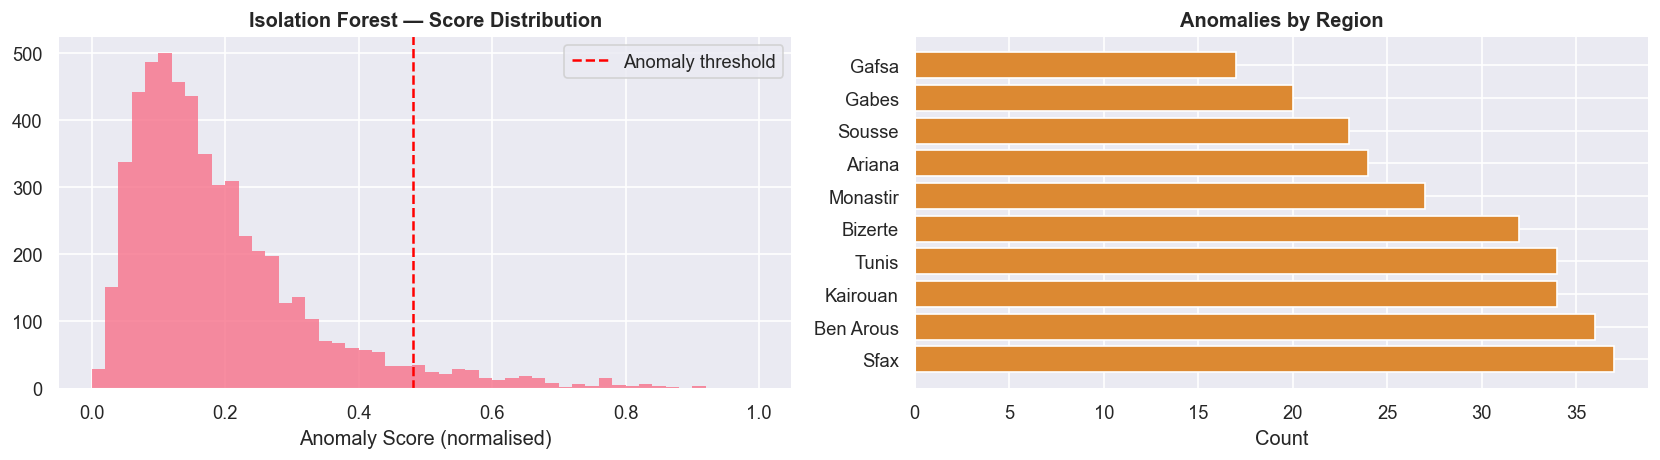

In [5]:
# 3.1 Anomaly score distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].hist(combined['if_score_norm'], bins=50, color=COLORS[0], alpha=0.8, edgecolor='none')
axes[0].axvline(combined[combined['if_anomaly']==1]['if_score_norm'].min(),
                color='red', linestyle='--', label='Anomaly threshold')
axes[0].set_title('Isolation Forest — Score Distribution', fontweight='bold')
axes[0].set_xlabel('Anomaly Score (normalised)')
axes[0].legend()

anomalies_by_region = (
    combined[combined['anomaly_flag']==1]
    ['region'].value_counts()
)
axes[1].barh(anomalies_by_region.index, anomalies_by_region.values, color=COLORS[1])
axes[1].set_title('Anomalies by Region', fontweight='bold')
axes[1].set_xlabel('Count')

plt.tight_layout()
plt.savefig(f'{FIGURES}/anomaly_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

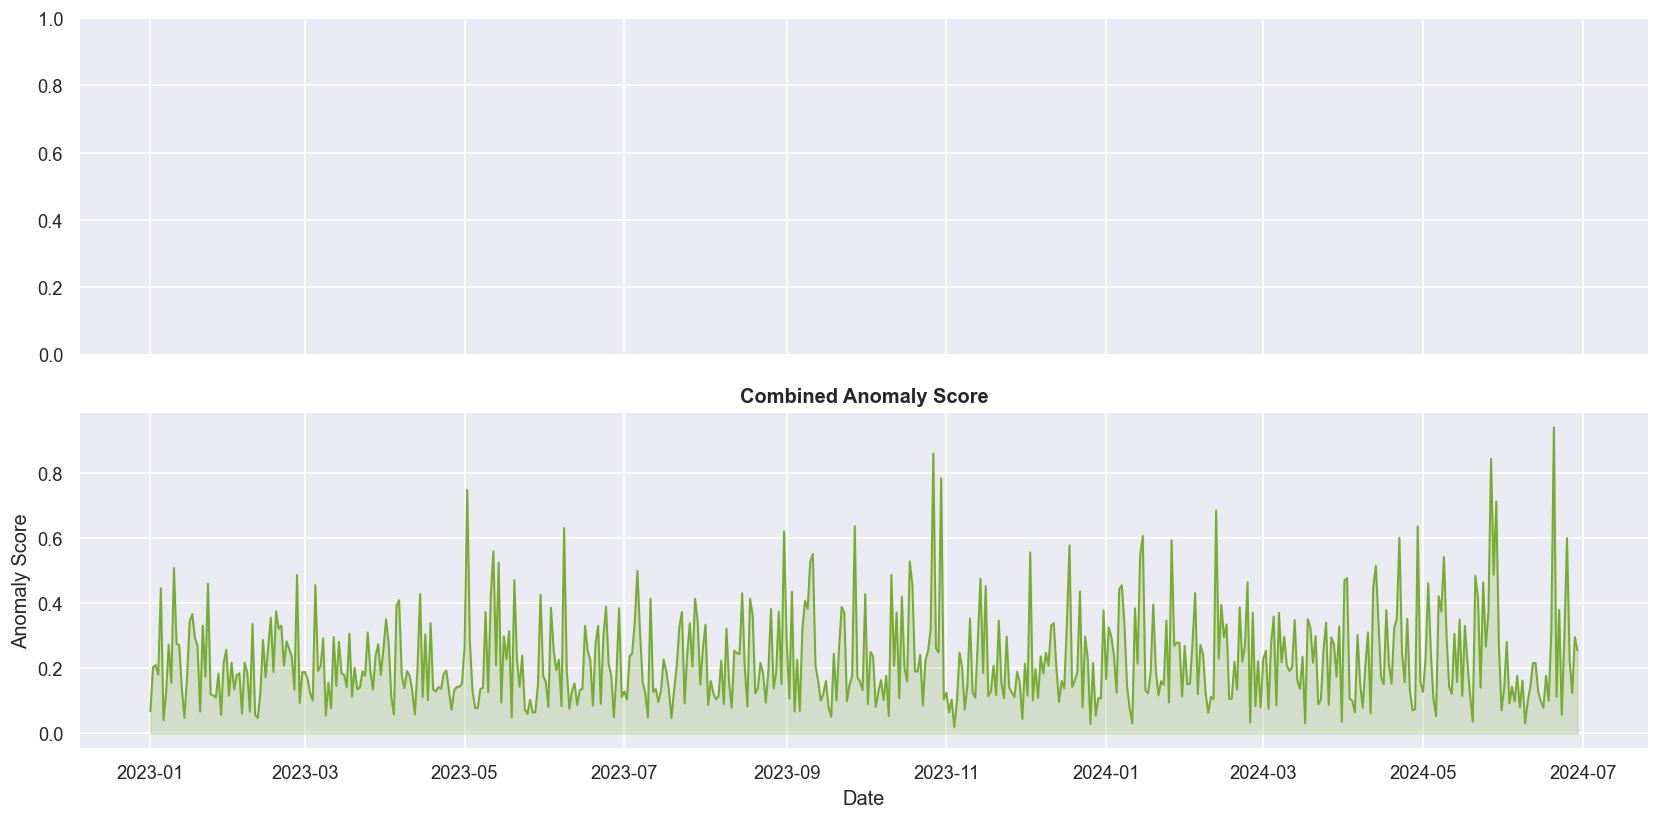

In [6]:
# 3.2 Anomalies on time series for one region
region = 'Tunis'
region_data = combined[combined['region'] == region].sort_values('date')
kpi_region  = kpi_agg[kpi_agg['region'] == region].sort_values('date')

fig, axes = plt.subplots(2, 1, figsize=(14, 7), sharex=True)

# QoE over time
if 'qoe_score_mean' in kpi_region.columns:
    axes[0].plot(kpi_region['date'], kpi_region['qoe_score_mean'],
                 linewidth=1.2, color=COLORS[2], label='QoE Mean')
    anomaly_dates = region_data[region_data['anomaly_flag']==1]['date']
    qoe_at_anomaly = kpi_region[kpi_region['date'].isin(anomaly_dates)]
    axes[0].scatter(qoe_at_anomaly['date'], qoe_at_anomaly['qoe_score_mean'],
                    color='red', s=50, zorder=5, label='Anomaly')
    axes[0].set_ylabel('QoE Score')
    axes[0].set_title(f'{region} — QoE Score with Anomaly Flags', fontweight='bold')
    axes[0].legend()

# Anomaly score over time
axes[1].plot(region_data['date'], region_data['combined_score'],
             color=COLORS[3], linewidth=1.2, label='Combined Score')
axes[1].fill_between(region_data['date'], region_data['combined_score'],
                      alpha=0.2, color=COLORS[3])
axes[1].set_ylabel('Anomaly Score')
axes[1].set_xlabel('Date')
axes[1].set_title('Combined Anomaly Score', fontweight='bold')

plt.tight_layout()
plt.savefig(f'{FIGURES}/anomaly_timeseries_{region.lower()}.png', dpi=150, bbox_inches='tight')
plt.show()

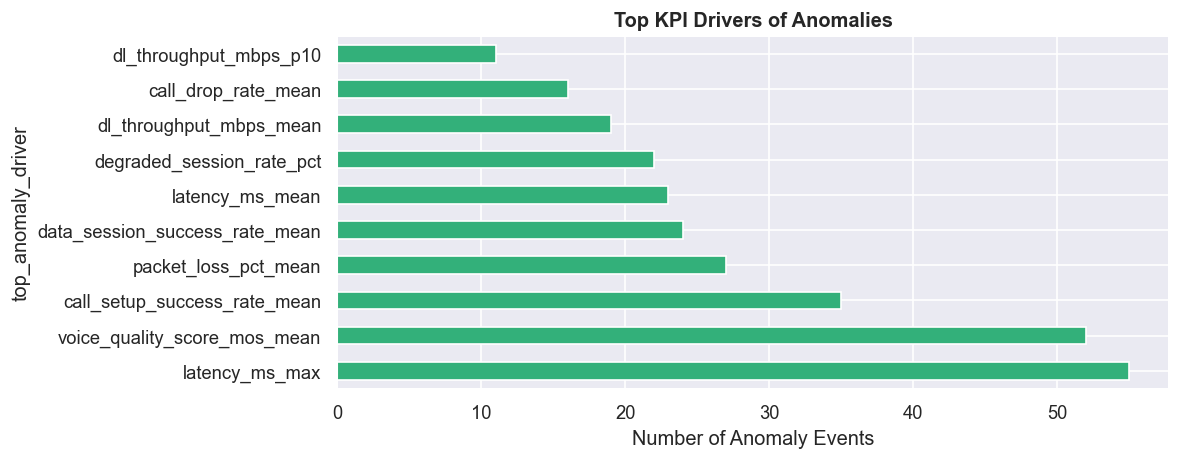

In [7]:
# 3.3 Top anomaly drivers
if 'top_anomaly_driver' in combined.columns:
    driver_counts = (
        combined[combined['anomaly_flag']==1]['top_anomaly_driver']
        .value_counts().head(10)
    )
    fig, ax = plt.subplots(figsize=(10, 4))
    driver_counts.plot(kind='barh', ax=ax, color=COLORS[4])
    ax.set_title('Top KPI Drivers of Anomalies', fontweight='bold')
    ax.set_xlabel('Number of Anomaly Events')
    plt.tight_layout()
    plt.savefig(f'{FIGURES}/anomaly_top_drivers.png', dpi=150, bbox_inches='tight')
    plt.show()

---
## 4. Model 2 — Spike Prediction
**ARIMA** + **Prophet** + **XGBoost** — best model selected per region

In [8]:
from src.models.spike_predictor import SpikePredictor

predictor = SpikePredictor()
pred_results = predictor.run(complaint_agg, feature_matrix)

summary_df = pred_results['summary']
print('\n=== MODEL PERFORMANCE SUMMARY ===')
display(summary_df[summary_df['is_best']].set_index('region')[['model','mae','rmse','mape']])

2026-03-30 06:13:14.103 | INFO     | src.models.spike_predictor:run:106 - =======================================================
2026-03-30 06:13:14.109 | INFO     | src.models.spike_predictor:run:107 - SPIKE PREDICTION
2026-03-30 06:13:14.112 | INFO     | src.models.spike_predictor:run:108 - =======================================================
2026-03-30 06:13:14.114 | INFO     | src.models.spike_predictor:run:111 - Training models for 10 regions × 3 model types

2026-03-30 06:13:14.116 | INFO     | src.models.spike_predictor:run:114 -   ── Region: Ariana ──────────────────────────
2026-03-30 06:13:14.902 | INFO     | src.models.spike_predictor:run:135 -     ARIMA  — MAE: 3.26  MAPE: 44.6%
06:13:15 - cmdstanpy - INFO - Chain [1] start processing
06:13:15 - cmdstanpy - INFO - Chain [1] done processing
2026-03-30 06:13:15.735 | INFO     | src.models.spike_predictor:run:150 -     Prophet— MAE: 3.41  MAPE: 48.3%
2026-03-30 06:13:16.284 | INFO     | src.models.spike_predictor:run:167 -


=== MODEL PERFORMANCE SUMMARY ===


,model,mae,rmse,mape
region,,,,
Ariana,xgboost,3.082,3.348,42.27
Ben Arous,prophet,2.086,2.486,19.63
Bizerte,arima,3.764,4.348,93.86
Gabes,prophet,3.166,3.633,45.94
Gafsa,prophet,2.938,3.153,40.79
Kairouan,prophet,1.287,1.494,12.48
Monastir,arima,3.650,3.965,40.47
Sfax,arima,2.596,3.256,28.93
Sousse,prophet,3.499,4.288,91.75


In [16]:
import matplotlib.pyplot as plt
print(plt.colormaps())

['magma', 'inferno', 'plasma', 'viridis', 'cividis', 'twilight', 'twilight_shifted', 'turbo', 'berlin', 'managua', 'vanimo', 'Blues', 'BrBG', 'BuGn', 'BuPu', 'CMRmap', 'GnBu', 'Greens', 'Greys', 'OrRd', 'Oranges', 'PRGn', 'PiYG', 'PuBu', 'PuBuGn', 'PuOr', 'PuRd', 'Purples', 'RdBu', 'RdGy', 'RdPu', 'RdYlBu', 'RdYlGn', 'Reds', 'Spectral', 'Wistia', 'YlGn', 'YlGnBu', 'YlOrBr', 'YlOrRd', 'afmhot', 'autumn', 'binary', 'bone', 'brg', 'bwr', 'cool', 'coolwarm', 'copper', 'cubehelix', 'flag', 'gist_earth', 'gist_gray', 'gist_heat', 'gist_ncar', 'gist_rainbow', 'gist_stern', 'gist_yarg', 'gnuplot', 'gnuplot2', 'gray', 'hot', 'hsv', 'jet', 'nipy_spectral', 'ocean', 'pink', 'prism', 'rainbow', 'seismic', 'spring', 'summer', 'terrain', 'winter', 'Accent', 'Dark2', 'Paired', 'Pastel1', 'Pastel2', 'Set1', 'Set2', 'Set3', 'tab10', 'tab20', 'tab20b', 'tab20c', 'grey', 'gist_grey', 'gist_yerg', 'Grays', 'magma_r', 'inferno_r', 'plasma_r', 'viridis_r', 'cividis_r', 'twilight_r', 'twilight_shifted_r', 't

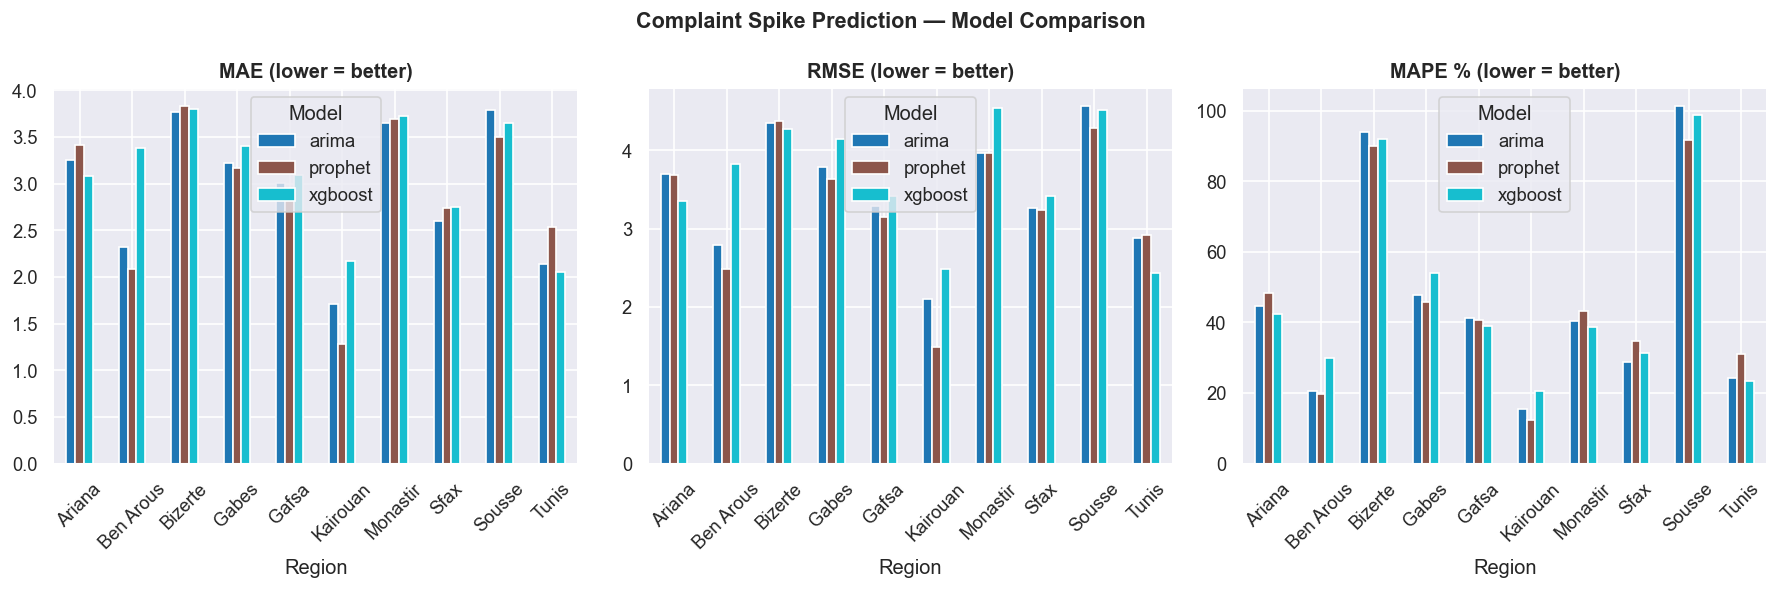

In [17]:
# 4.1 Model comparison bar chart
from matplotlib import pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
metrics_list = ['mae', 'rmse', 'mape']
titles = ['MAE (lower = better)', 'RMSE (lower = better)', 'MAPE % (lower = better)']

for ax, metric, title in zip(axes, metrics_list, titles):
    pivot = summary_df.pivot(index='region', columns='model', values=metric)
    pivot.plot(kind='bar', ax=ax, colormap='tab10')  # Utilisation de 'tab10', un colormap valide
    ax.set_title(title, fontweight='bold')
    ax.set_xlabel('Region')
    ax.tick_params(axis='x', rotation=45)
    ax.legend(title='Model')

plt.suptitle('Complaint Spike Prediction — Model Comparison', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{FIGURES}/spike_prediction_model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

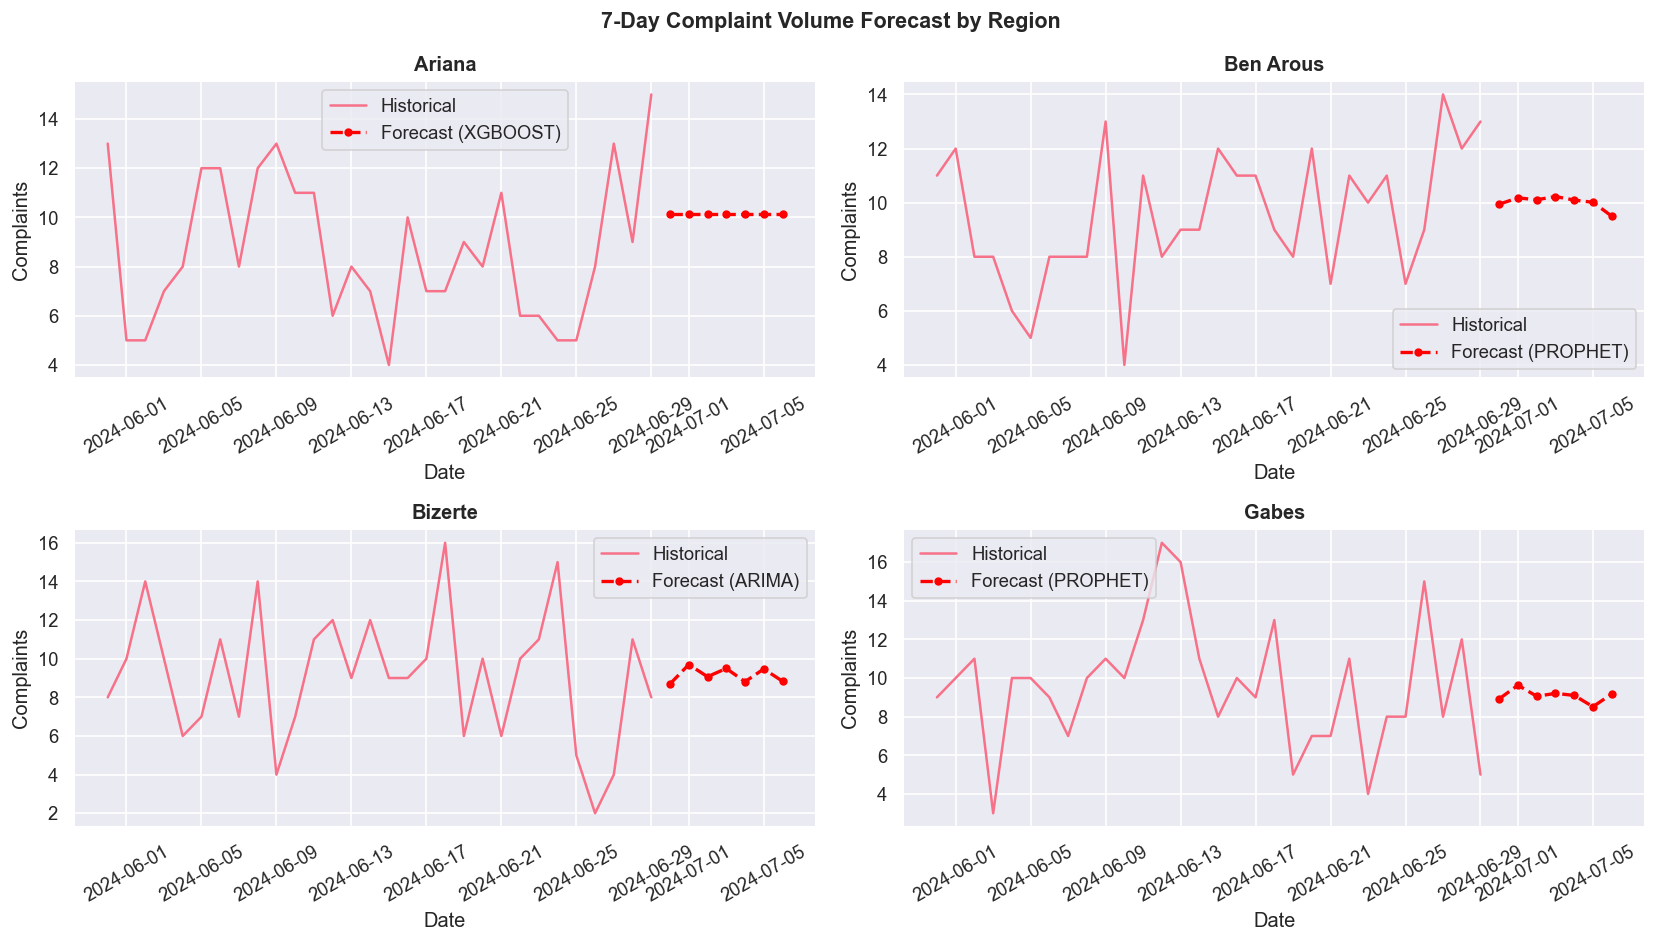

In [18]:
# 4.2 7-day forecast chart per region
forecast_df = pred_results['forecasts']
regions_to_plot = forecast_df['region'].unique()[:4]

fig, axes = plt.subplots(2, 2, figsize=(14, 8))
axes = axes.flatten()

for i, region in enumerate(regions_to_plot):
    # Historical
    hist = complaint_agg[complaint_agg['region'] == region].sort_values('date').tail(30)
    fc   = forecast_df[forecast_df['region'] == region]
    
    axes[i].plot(pd.to_datetime(hist['date']), hist['total_complaints'],
                 color=COLORS[0], linewidth=1.5, label='Historical')
    axes[i].plot(pd.to_datetime(fc['date']), fc['forecast'],
                 color='red', linewidth=2, linestyle='--', marker='o', markersize=4,
                 label=f"Forecast ({fc['model_used'].iloc[0].upper()})")
    axes[i].set_title(f'{region}', fontweight='bold')
    axes[i].set_xlabel('Date')
    axes[i].set_ylabel('Complaints')
    axes[i].legend()
    axes[i].tick_params(axis='x', rotation=30)

plt.suptitle('7-Day Complaint Volume Forecast by Region', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{FIGURES}/spike_7day_forecast.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 5. Model 3 — Root Cause Classification
**Random Forest** + **XGBoost** with SHAP explainability

In [19]:
from src.models.root_cause_classifier import RootCauseClassifier

clf = RootCauseClassifier()
clf_results = clf.run(complaints_clean, feature_matrix)

print('\n=== CLASSIFICATION RESULTS ===')
print(f"Best model : {clf_results['best_model'].upper()}")
print(f"RF  F1-macro: {clf_results['rf_report']['f1_macro']:.3f}  "
      f"Accuracy: {clf_results['rf_report']['accuracy']:.3f}")
print(f"XGB F1-macro: {clf_results['xgb_report']['f1_macro']:.3f}  "
      f"Accuracy: {clf_results['xgb_report']['accuracy']:.3f}")

2026-03-30 06:21:12.938 | INFO     | src.models.root_cause_classifier:run:126 - =======================================================
2026-03-30 06:21:12.940 | INFO     | src.models.root_cause_classifier:run:127 - ROOT CAUSE CLASSIFICATION
2026-03-30 06:21:12.941 | INFO     | src.models.root_cause_classifier:run:128 - =======================================================
2026-03-30 06:21:12.942 | INFO     | src.models.root_cause_classifier:run:131 - 
[1/4] Building labelled dataset ...
2026-03-30 06:21:16.114 | INFO     | src.models.root_cause_classifier:_build_dataset:236 -   Dataset: 5,459 rows × 29 features  | 5 classes
2026-03-30 06:21:16.116 | INFO     | src.models.root_cause_classifier:_build_dataset:240 -   Class distribution:
Data_Performance      2682
Voice_Quality         1324
Coverage              1072
Network_Congestion     255
Other                  126
2026-03-30 06:21:16.119 | INFO     | src.models.root_cause_classifier:run:138 -   Classes (5): ['Coverage', 'Data_Per


=== CLASSIFICATION RESULTS ===
Best model : RANDOM_FOREST
RF  F1-macro: 0.180  Accuracy: 0.404
XGB F1-macro: 0.178  Accuracy: 0.545


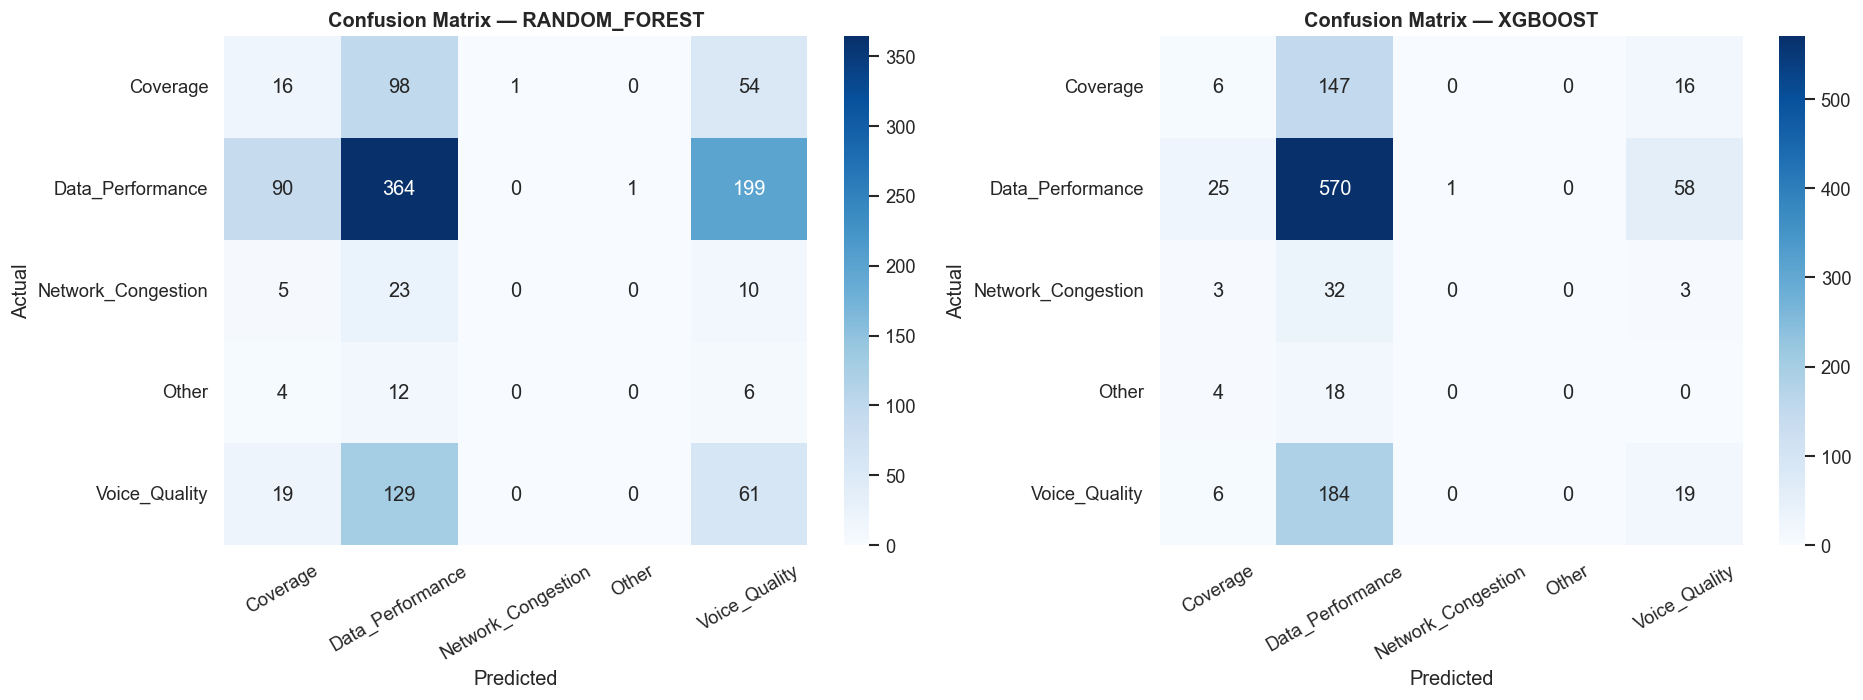

In [20]:
# 5.1 Confusion matrices side by side
classes = clf_results['classes']
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for ax, (model_name, cm) in zip(axes, clf_results['confusion_matrices'].items()):
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=classes, yticklabels=classes)
    ax.set_title(f'Confusion Matrix — {model_name.upper()}', fontweight='bold')
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')
    ax.tick_params(axis='x', rotation=30)
    ax.tick_params(axis='y', rotation=0)

plt.tight_layout()
plt.savefig(f'{FIGURES}/confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()

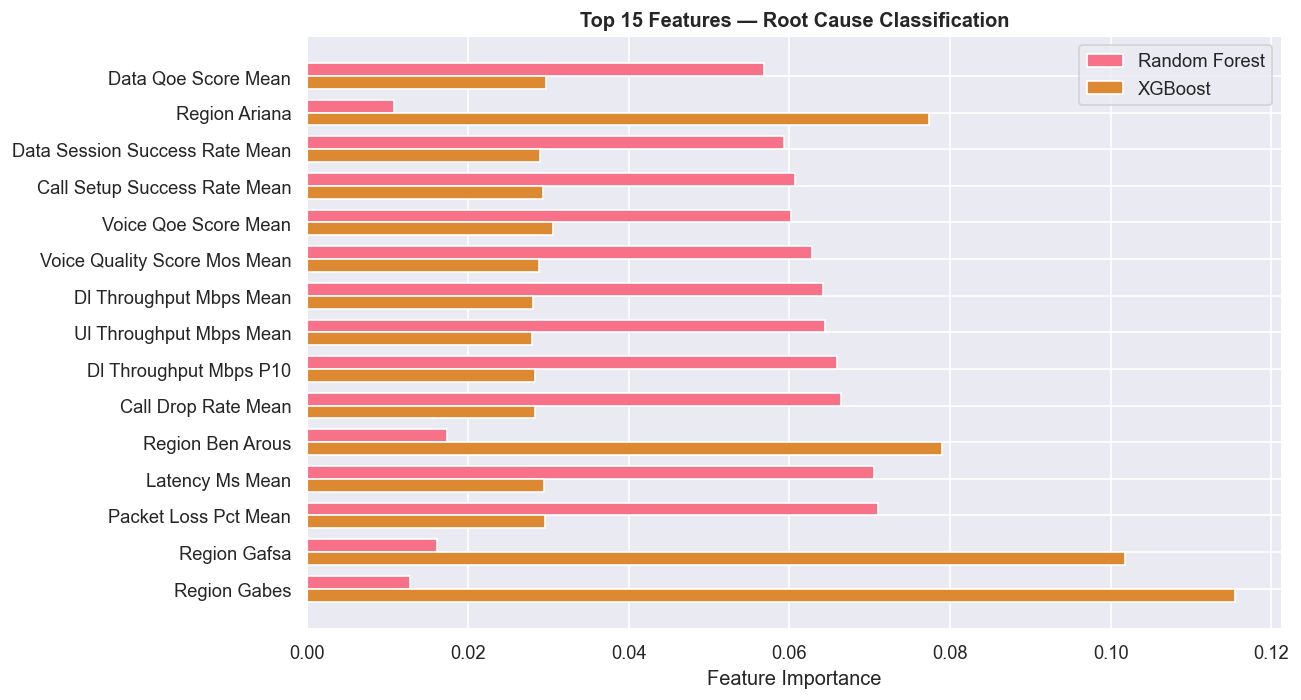

In [21]:
# 5.2 Feature importance comparison
fi = clf_results['feature_importance'].head(15)

fig, ax = plt.subplots(figsize=(11, 6))
x = np.arange(len(fi))
width = 0.35

ax.barh(x + width/2, fi['importance_rf'],  width, label='Random Forest', color=COLORS[0])
ax.barh(x - width/2, fi['importance_xgb'], width, label='XGBoost',       color=COLORS[1])
ax.set_yticks(x)
ax.set_yticklabels([c.replace('_', ' ').title() for c in fi['feature']])
ax.set_xlabel('Feature Importance')
ax.set_title('Top 15 Features — Root Cause Classification', fontweight='bold')
ax.legend()
plt.tight_layout()
plt.savefig(f'{FIGURES}/root_cause_feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

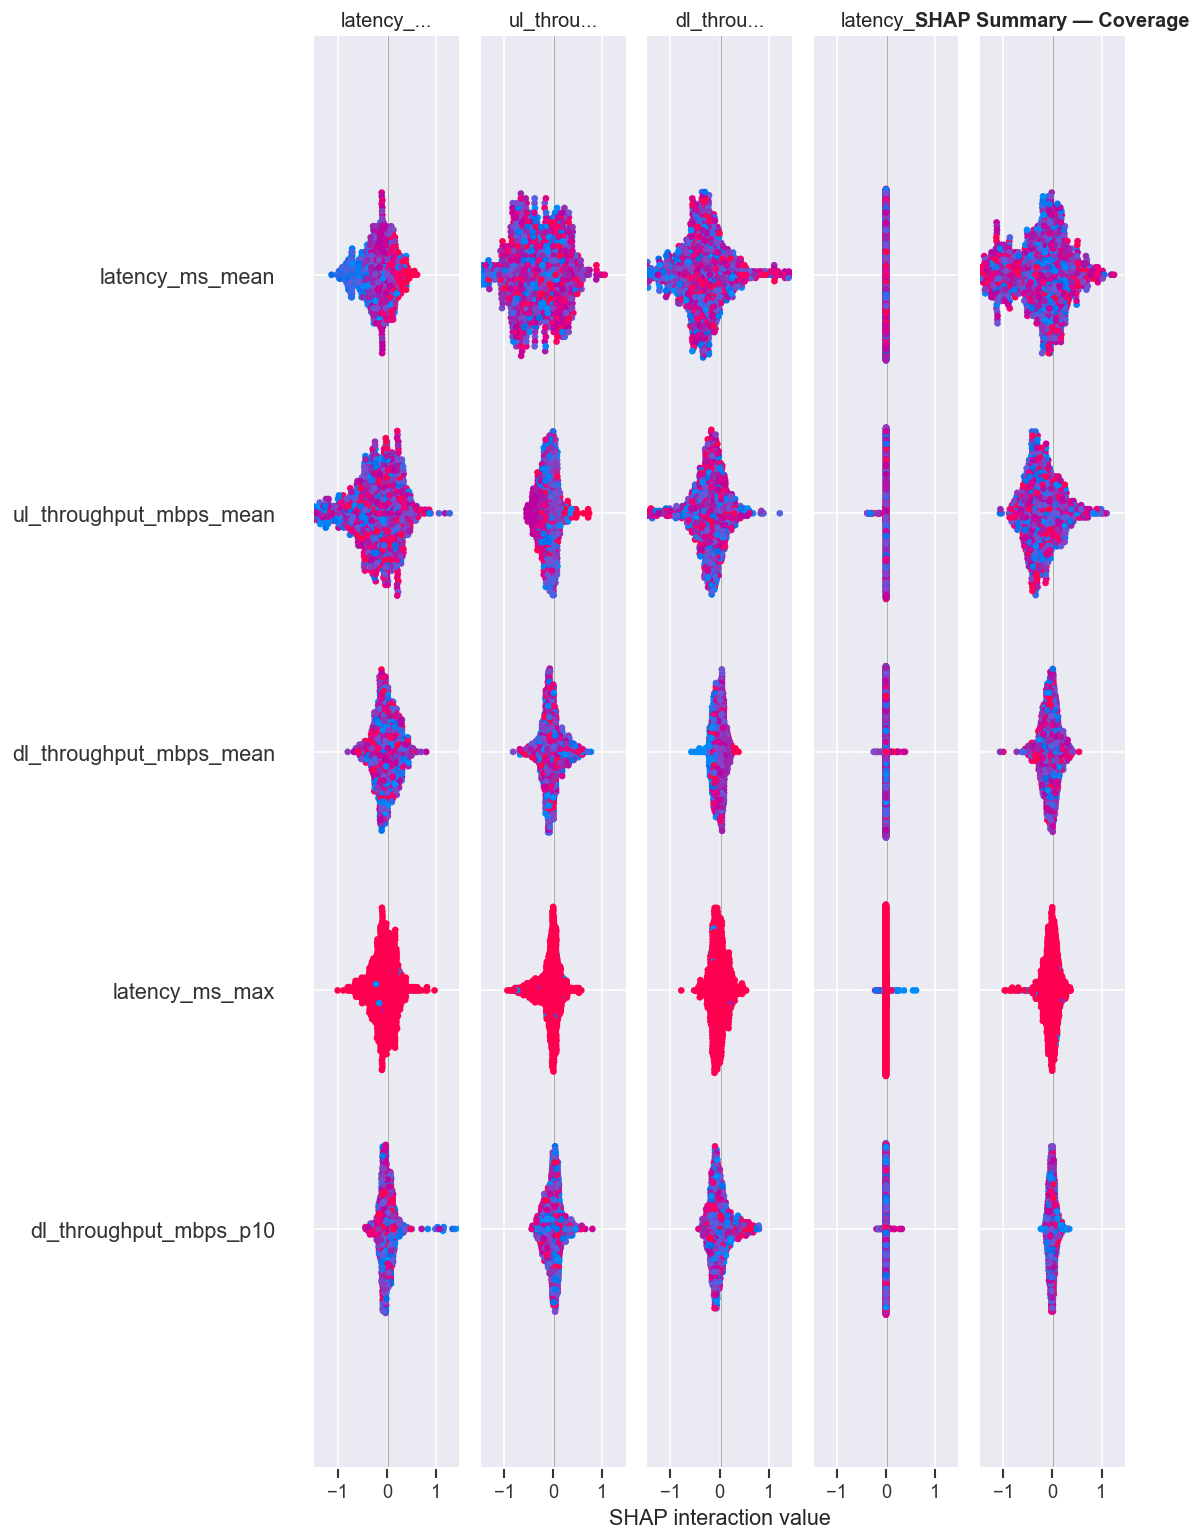

SHAP plot saved ✓


In [22]:
# 5.3 SHAP summary plot (if available)
try:
    import shap
    shap_vals = clf_results['shap_values']
    X_test    = clf_results['X_test']
    if shap_vals is not None and X_test is not None:
        # Multi-class: plot for class 0
        shap.summary_plot(
            shap_vals[0] if isinstance(shap_vals, list) else shap_vals,
            X_test,
            feature_names=clf_results['feature_cols'],
            max_display=15,
            show=False
        )
        plt.title(f"SHAP Summary — {clf_results['classes'][0]}", fontweight='bold')
        plt.tight_layout()
        plt.savefig(f"{FIGURES}/shap_summary.png", dpi=150, bbox_inches='tight')
        plt.show()
        print('SHAP plot saved ✓')
    else:
        print('SHAP values not computed')
except Exception as e:
    print(f'SHAP plot skipped: {e}')

In [23]:
# 5.4 Per-class classification report
best_report = clf_results['xgb_report']['classification_report']
report_df = pd.DataFrame(best_report).T
display(report_df.round(3))

,precision,recall,f1-score,support
Coverage,0.136,0.036,0.056,169.000
Data_Performance,0.599,0.872,0.710,654.000
Network_Congestion,0.000,0.000,0.000,38.000
Other,0.000,0.000,0.000,22.000
Voice_Quality,0.198,0.091,0.125,209.000
accuracy,0.545,0.545,0.545,0.545
macro avg,0.187,0.200,0.178,1092.000
weighted avg,0.418,0.545,0.458,1092.000


---
## 6. Model 4 — Customer Clustering
**K-Means** + **DBSCAN** — user experience profiling

In [24]:
from src.models.customer_clustering import CustomerClusterer

clusterer = CustomerClusterer()
clust_results = clusterer.run(kpi_clean, complaints_clean)

print(f"\nOptimal K: {clust_results['optimal_k']}")
print(f"K-Means silhouette: {clust_results['kmeans_results']['silhouette_score']}")
print(f"DBSCAN clusters: {clust_results['dbscan_results']['n_clusters']}")

2026-03-30 06:23:20.192 | INFO     | src.models.customer_clustering:run:118 - =======================================================
2026-03-30 06:23:20.195 | INFO     | src.models.customer_clustering:run:119 - CUSTOMER CLUSTERING
2026-03-30 06:23:20.197 | INFO     | src.models.customer_clustering:run:120 - =======================================================
2026-03-30 06:23:20.199 | INFO     | src.models.customer_clustering:run:123 - 
[1/5] Building per-user feature matrix ...
2026-03-30 06:23:22.159 | INFO     | src.models.customer_clustering:_build_user_features:207 -   User feature matrix: 5,000 users × 37 cols
2026-03-30 06:23:22.160 | INFO     | src.models.customer_clustering:run:127 - 
[2/5] Scaling and applying PCA ...
2026-03-30 06:23:22.185 | INFO     | src.models.customer_clustering:_scale_and_reduce:228 -   PCA variance explained (2 components): 52.1%
2026-03-30 06:23:22.187 | INFO     | src.models.customer_clustering:run:131 - 
[3/5] Selecting optimal K ...
2026-03-30


Optimal K: 2
K-Means silhouette: 0.213
DBSCAN clusters: 1


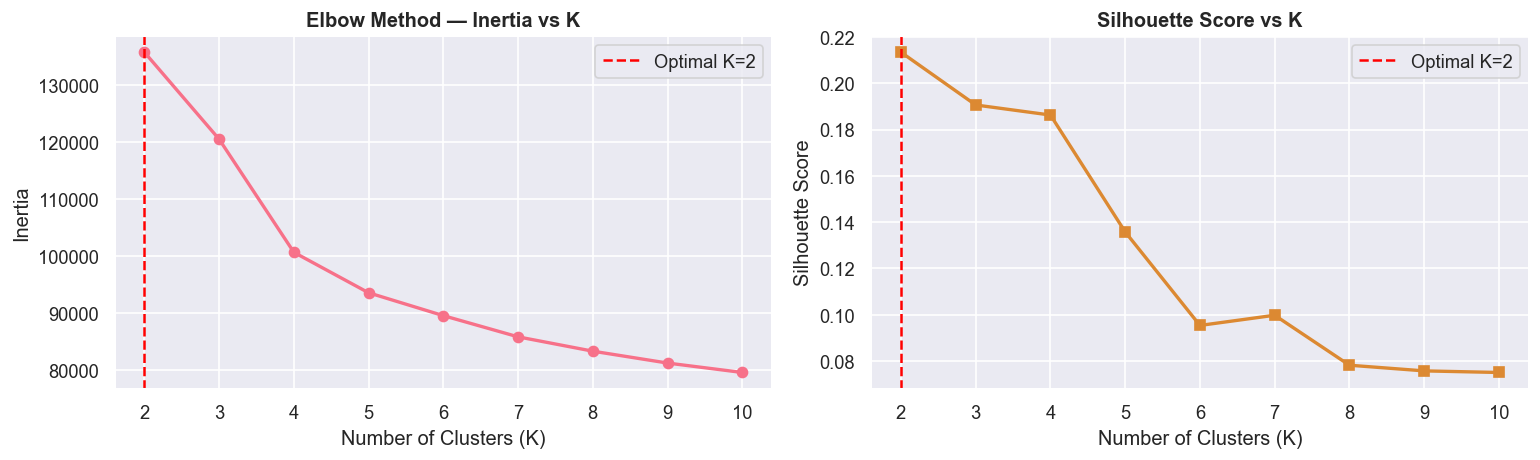

In [25]:
# 6.1 Elbow + Silhouette plots
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

k_vals   = clust_results['elbow_data']['k']
inertias = clust_results['elbow_data']['inertia']
axes[0].plot(k_vals, inertias, marker='o', color=COLORS[0], linewidth=2)
axes[0].axvline(clust_results['optimal_k'], color='red', linestyle='--', label=f"Optimal K={clust_results['optimal_k']}")
axes[0].set_title('Elbow Method — Inertia vs K', fontweight='bold')
axes[0].set_xlabel('Number of Clusters (K)')
axes[0].set_ylabel('Inertia')
axes[0].legend()

sil_k    = clust_results['silhouette_data']['k']
sil_sc   = clust_results['silhouette_data']['score']
axes[1].plot(sil_k, sil_sc, marker='s', color=COLORS[1], linewidth=2)
axes[1].axvline(clust_results['optimal_k'], color='red', linestyle='--', label=f"Optimal K={clust_results['optimal_k']}")
axes[1].set_title('Silhouette Score vs K', fontweight='bold')
axes[1].set_xlabel('Number of Clusters (K)')
axes[1].set_ylabel('Silhouette Score')
axes[1].legend()

plt.tight_layout()
plt.savefig(f'{FIGURES}/clustering_k_selection.png', dpi=150, bbox_inches='tight')
plt.show()

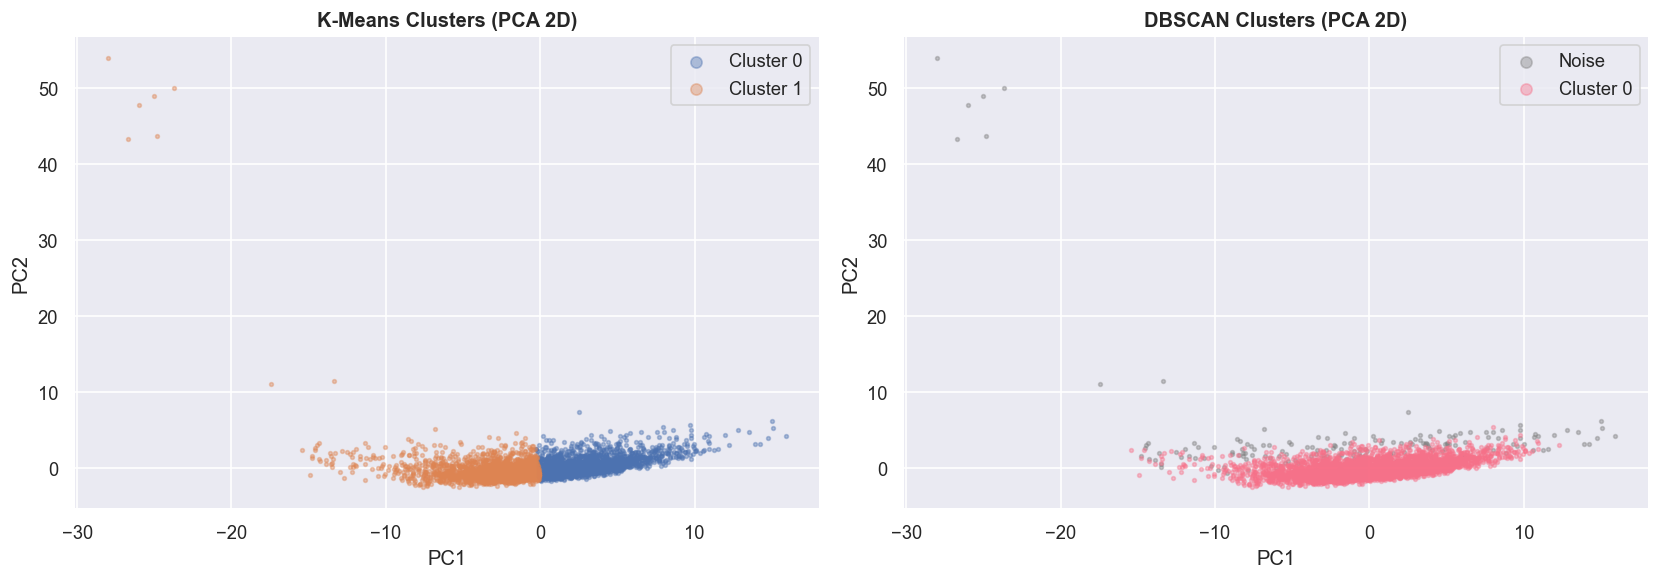

In [26]:
# 6.2 PCA scatter — K-Means vs DBSCAN
user_df = clust_results['user_profiles']
db_df   = clust_results['dbscan_results']['user_df']

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# K-Means
for k in sorted(user_df['kmeans_cluster'].unique()):
    mask = user_df['kmeans_cluster'] == k
    axes[0].scatter(user_df.loc[mask, 'pca_x'], user_df.loc[mask, 'pca_y'],
                    s=5, alpha=0.4, label=f'Cluster {k}')
axes[0].set_title('K-Means Clusters (PCA 2D)', fontweight='bold')
axes[0].set_xlabel('PC1'); axes[0].set_ylabel('PC2')
axes[0].legend(markerscale=3, loc='best')

# DBSCAN
db_labels = sorted(db_df['dbscan_cluster'].unique())
for label in db_labels:
    mask  = db_df['dbscan_cluster'] == label
    color = 'grey' if label == -1 else COLORS[label % len(COLORS)]
    name  = 'Noise' if label == -1 else f'Cluster {label}'
    axes[1].scatter(db_df.loc[mask, 'pca_x'], db_df.loc[mask, 'pca_y'],
                    s=5, alpha=0.4, color=color, label=name)
axes[1].set_title('DBSCAN Clusters (PCA 2D)', fontweight='bold')
axes[1].set_xlabel('PC1'); axes[1].set_ylabel('PC2')
axes[1].legend(markerscale=3, loc='best')

plt.tight_layout()
plt.savefig(f'{FIGURES}/clustering_pca_scatter.png', dpi=150, bbox_inches='tight')
plt.show()

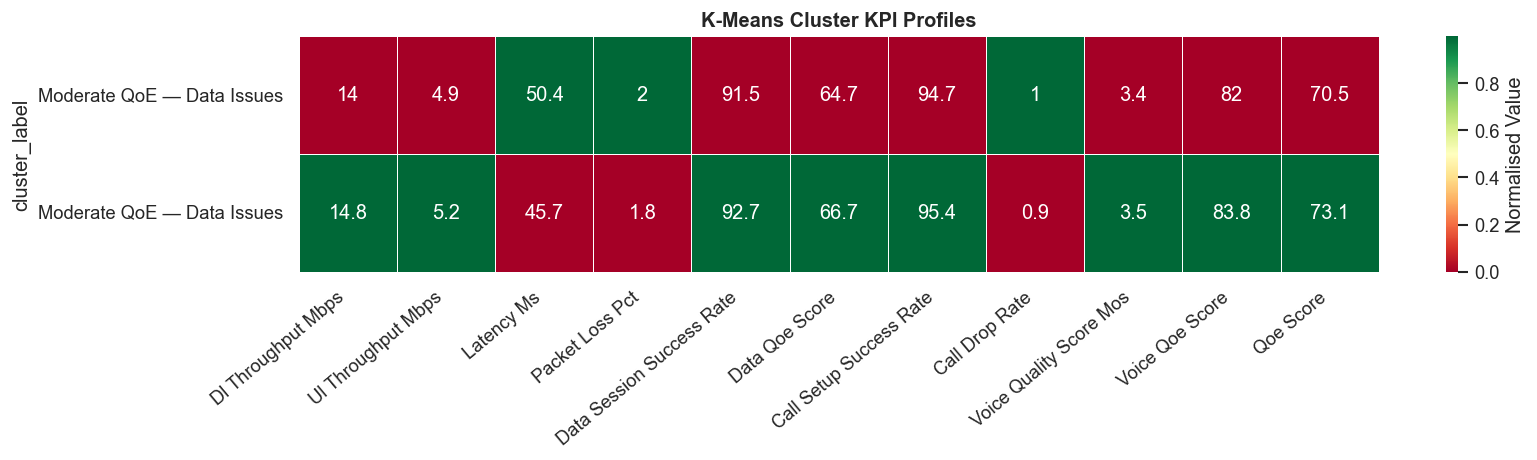


=== CLUSTER PROFILES ===


' kmeans_cluster              cluster_label  n_users  pct_of_users\n              0 Moderate QoE — Data Issues     2615          52.3\n              1 Moderate QoE — Data Issues     2385          47.7'

In [27]:
# 6.3 Cluster profile heatmap
profiles = clust_results['cluster_profiles']['kmeans']
kpi_mean_cols = [c for c in profiles.columns
                  if '_mean' in c and 'n_users' not in c]

if kpi_mean_cols:
    heatmap_data = profiles.set_index('cluster_label')[kpi_mean_cols]
    heatmap_norm = (heatmap_data - heatmap_data.min()) / (heatmap_data.max() - heatmap_data.min() + 1e-9)

    fig, ax = plt.subplots(figsize=(14, max(4, len(profiles))))
    sns.heatmap(heatmap_norm, annot=heatmap_data.round(1), fmt='g',
                cmap='RdYlGn', ax=ax, linewidths=0.5,
                cbar_kws={'label': 'Normalised Value'})
    ax.set_title('K-Means Cluster KPI Profiles', fontweight='bold')
    ax.set_xticklabels([c.replace('_mean','').replace('_',' ').title()
                         for c in kpi_mean_cols], rotation=40, ha='right')
    plt.tight_layout()
    plt.savefig(f'{FIGURES}/cluster_profiles_heatmap.png', dpi=150, bbox_inches='tight')
    plt.show()

# Print profile table
print('\n=== CLUSTER PROFILES ===')
display(profiles[['kmeans_cluster','cluster_label','n_users','pct_of_users']].to_string(index=False))

---
## 7. Model Performance Summary — D4 Deliverable

In [28]:
print('=' * 60)
print('  D4 — ML MODEL PERFORMANCE SUMMARY')
print('=' * 60)

print(f"""
┌─────────────────────────────────────────────────────────┐
│  MODEL 1 — ANOMALY DETECTION                            │
│  Isolation Forest + Z-score/CUSUM                       │
│  Anomaly rate : {metrics['anomaly_rate_pct']:.1f}%                               │
│  Consensus    : {metrics['consensus_anomalies']} records flagged by both models       │
├─────────────────────────────────────────────────────────┤
│  MODEL 2 — SPIKE PREDICTION                             │
│  Best model per region (ARIMA / Prophet / XGBoost)      │
│  Avg MAE  : {pred_results['summary'][pred_results['summary']['is_best']]['mae'].mean():.2f} complaints/day                        │
│  Avg MAPE : {pred_results['summary'][pred_results['summary']['is_best']]['mape'].mean():.1f}%                                   │
├─────────────────────────────────────────────────────────┤
│  MODEL 3 — ROOT CAUSE CLASSIFICATION                    │
│  Best: {clf_results['best_model'].upper():<15}                            │
│  F1-macro : {clf_results['xgb_report']['f1_macro']:.3f}                                   │
│  Accuracy : {clf_results['xgb_report']['accuracy']:.3f}                                   │
├─────────────────────────────────────────────────────────┤
│  MODEL 4 — CUSTOMER CLUSTERING                          │
│  K-Means   : {clust_results['optimal_k']} clusters (silhouette={clust_results['kmeans_results']['silhouette_score']})  │
│  DBSCAN    : {clust_results['dbscan_results']['n_clusters']} clusters                                │
└─────────────────────────────────────────────────────────┘
""")

print('\nAll model artifacts saved to models/ directory ✓')
print('All figures saved to reports/figures/ ✓')

  D4 — ML MODEL PERFORMANCE SUMMARY

┌─────────────────────────────────────────────────────────┐
│  MODEL 1 — ANOMALY DETECTION                            │
│  Isolation Forest + Z-score/CUSUM                       │
│  Anomaly rate : 5.2%                               │
│  Consensus    : 4 records flagged by both models       │
├─────────────────────────────────────────────────────────┤
│  MODEL 2 — SPIKE PREDICTION                             │
│  Best model per region (ARIMA / Prophet / XGBoost)      │
│  Avg MAE  : 2.81 complaints/day                        │
│  Avg MAPE : 44.0%                                   │
├─────────────────────────────────────────────────────────┤
│  MODEL 3 — ROOT CAUSE CLASSIFICATION                    │
│  Best: RANDOM_FOREST                              │
│  F1-macro : 0.178                                   │
│  Accuracy : 0.545                                   │
├─────────────────────────────────────────────────────────┤
│  MODEL 4 — CUSTOMER CLUSTE